# Coral Bleaching Prediction with Machine Learning

## Global Coral Bleaching Database

### Autore
**Giovanna Chessa Orrù**

### Dataset
Global Coral Bleaching Database (GCBD)

Fonte: https://www.kaggle.com/datasets/mehrdat/coral-reef-global-bleaching$0


### Obiettivo del progetto

L'obiettivo di questo progetto è sviluppare un modello di Machine Learning in grado di prevedere la presenza di fenomeni di coral bleaching utilizzando variabili ambientali, climatiche e geografiche.

Le principali fasi del progetto sono:

- pulizia dei dati;
- suddivisione in training, validation e test set;
- analisi esplorativa dei dati (EDA);
- costruzione di una pipeline di preprocessing;
- addestramento e valutazione di modelli di classificazione;
- scelta e analisi del modello più performante;
- valutazione finale sul test set;
- discussione delle conclusioni e dei limiti del progetto.

### Nota sull’esecuzione

Il notebook si aspetta il file `coral.csv` nella stessa cartella del notebook. Se il dataset è salvato in una posizione diversa, è necessario modificare la variabile `PATH`.


# **1. Importazione delle librerie**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn: suddivisione dei dati e validazione
from sklearn.model_selection import (
    GroupShuffleSplit,
    GroupKFold,
    GridSearchCV,
    
)

# scikit-learn: preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, OneHotEncoder

# scikit-learn: modelli di classificazione
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# scikit-learn: metriche di valutazione
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)


# **2. Caricamento del dataset**



In [2]:
PATH = 'coral.csv'
df = pd.read_csv(PATH, low_memory=False)
print("Numero di righe (osservazioni):", df.shape[0])
print("Numero di colonne (variabili):", df.shape[1])



Numero di righe (osservazioni): 41361
Numero di colonne (variabili): 62


In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# **3. Data Cleaning e comprensione strutturale del dataset**

In questa sezione vengono svolte esclusivamente le operazioni necessarie a rendere i dati utilizzabili e a **comprendere la struttura** del dataset. 

Durante la pulizia ci si limita a rendere i dati leggibili e a comprenderne la struttura. L’analisi esplorativa viene svolta dopo lo split e solo sul training set: osservare tutti i dati prima della suddivisione potrebbe condizionare le scelte di modellazione anche sulla base di validation e test

## 3.1 Correzione dei tipi di dato



In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41361 entries, 0 to 41360
Data columns (total 62 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Site_ID                                41361 non-null  int64  
 1   Sample_ID                              41361 non-null  int64  
 2   Data_Source                            41361 non-null  object 
 3   Latitude_Degrees                       41361 non-null  float64
 4   Longitude_Degrees                      41361 non-null  float64
 5   Ocean_Name                             41361 non-null  object 
 6   Reef_ID                                41361 non-null  object 
 7   Realm_Name                             41361 non-null  object 
 8   Ecoregion_Name                         41361 non-null  object 
 9   Country_Name                           41361 non-null  object 
 10  State_Island_Province_Name             41361 non-null  object 
 11  Ci

### Perché alcune variabili numeriche risultano di tipo object?

Diverse colonne che dovrebbero essere numeriche (temperature, indici di stress termico, profondità, ecc.) risultano di tipo `object`. Osservando qualche riga è possibile comprenderne il motivo.

In [5]:
df.head()

,Site_ID,Sample_ID,Data_Source,Latitude_Degrees,Longitude_Degrees,Ocean_Name,Reef_ID,Realm_Name,Ecoregion_Name,Country_Name,State_Island_Province_Name,City_Town_Name,Site_Name,Distance_to_Shore,Exposure,Turbidity,Cyclone_Frequency,Date_Day,Date_Month,Date_Year,Depth_m,Substrate_Name,Percent_Cover,Bleaching_Level,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,Windspeed,SSTA,SSTA_Standard_Deviation,SSTA_Mean,SSTA_Minimum,SSTA_Maximum,SSTA_Frequency,SSTA_Frequency_Standard_Deviation,SSTA_FrequencyMax,SSTA_FrequencyMean,SSTA_DHW,SSTA_DHW_Standard_Deviation,SSTA_DHWMax,SSTA_DHWMean,TSA,TSA_Standard_Deviation,TSA_Minimum,TSA_Maximum,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Date,Site_Comments,Sample_Comments,Bleaching_Comments
0,2501,10324336,Donner,23.163,-82.526,Atlantic,nd,Tropical Atlantic,Cuba and Cayman Islands,Cuba,Havana,Havana,Puntilla,8519.23,Exposed,0.0287,49.900,15,9,2005,10,nd,nd,nd,50.2,301.61,302.05,300.67,296.72,304.69,1.6,8,-0.46,1,0,-3.56,2.24,0,3.13,17,3,0,1.63,7.88,0.98,-0.8,1.6,-6.12,1.83,-2.17,0,1.09,5,0,0,0.74,7.25,0.18,2005-09-15,nd,nd,nd
1,3467,10324754,Donner,-17.575,-149.783,Pacific,nd,Eastern Indo-Pacific,Society Islands French Polynesia,French Polynesia,Society Islands,Moorea,nd,1431.62,Exposed,0.0262,51.200,15,3,1991,14,nd,nd,nd,50.7,262.15,303.30,300.73,297.58,305.01,1.12,2,1.29,1,0,-2.73,3.1,0.5,2.77,13.25,2,0.26,1.48,11.41,0.72,1.29,1.12,-4.42,3.00,-1.26,0.25,0.93,4,0,0.26,0.67,4.65,0.19,1991-03-15,The bleaching does not appear to have gained ...,The bleaching does not appear to have gained ...,nd
2,1794,10323866,Donner,18.369,-64.564,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United Kingdom,British Virgin Islands,Peter Island,Coral Gardens,182.33,Exposed,0.0429,61.520,15,1,2006,7,nd,nd,nd,50.9,298.79,299.18,300.32,297.12,304.14,1.22,8,0.04,1,0,-2.92,2.83,16,4.52,23,3,0,2.45,16.24,1.26,-2.64,1.22,-4.69,2.31,-1.49,7,1.31,7,0,0,1.04,11.66,0.26,2006-01-15,nd,nd,nd
3,8647,10328028,Donner,17.760,-64.568,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,US Virgin Islands,St. Croix,3219,313.13,Exposed,0.0424,65.390,15,4,2006,9.02,nd,nd,nd,50.9,300.16,299.61,300.38,297.25,304.07,1.19,3,-0.07,1,0,-2.77,2.47,22,4.75,24,3,0,2.37,16.73,1.07,-2.27,1.19,-4.63,2.19,-1.49,3,0.94,4,0,0,0.75,5.64,0.2,2006-04-15,nd,nd,nd
4,8648,10328029,Donner,17.769,-64.583,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,US Virgin Islands,St. Croix,3194,792,Exposed,0.0424,65.390,15,4,2006,12.50,nd,nd,nd,50.9,300.15,299.7,300.38,296.63,303.76,1.18,3,0,1,0,-2.84,2.3,16,4.16,20,3,0,2.24,13.86,1.16,-2.19,1.18,-5.25,1.87,-1.5,3,1.33,5,0,0,0.92,6.89,0.25,2006-04-15,nd,nd,nd


Compare il valore `"nd"` (*no data*), usato nel dataset per segnalare un dato mancante. La sua presenza forza pandas a trattare l'intera colonna come testo. Sostituiamo quindi `"nd"` con `NaN` e convertiamo esplicitamente in formato numerico le colonne che, per definizione del dataset, sono quantità fisiche.

In [6]:
# Sostituiamo il marcatore 'nd' con NaN in tutto il dataframe
df_clean = df.replace('nd', np.nan)

# Colonne che, per definizione del dataset, sono fisicamente numeriche
# ma che pandas ha letto come testo a causa degli 'nd'
numeric_cols = [
    'Distance_to_Shore', 'Turbidity', 'Depth_m', 'Percent_Cover',
    'Percent_Bleaching', 'ClimSST', 'Temperature_Kelvin', 'Temperature_Mean',
    'Temperature_Minimum', 'Temperature_Maximum', 'Temperature_Kelvin_Standard_Deviation',
    'Windspeed', 'SSTA', 'SSTA_Standard_Deviation', 'SSTA_Mean', 'SSTA_Minimum', 'SSTA_Maximum',
    'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation', 'SSTA_FrequencyMax', 'SSTA_FrequencyMean',
    'SSTA_DHW', 'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean',
    'TSA', 'TSA_Standard_Deviation', 'TSA_Minimum', 'TSA_Maximum', 'TSA_Mean',
    'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax', 'TSA_FrequencyMean',
    'TSA_DHW', 'TSA_DHW_Standard_Deviation', 'TSA_DHWMax', 'TSA_DHWMean'
]

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print("Controllo dtypes dopo la conversione:")
print(df_clean[numeric_cols].dtypes.value_counts())

Controllo dtypes dopo la conversione:
float64    38
Name: count, dtype: int64


Dopo la conversione tutte le colonne indicate risultano numeriche (`float64`): il marcatore testuale è stato correttamente interpretato come valore mancante.

## 3.2 Controllo delle osservazioni duplicate

Verifichiamo la presenza di osservazioni ripetute. Due righe che coincidono su tutte le variabili di misura ma differiscono solo per identificativi amministrativi o campi di testo libero rappresentano la stessa osservazione: confrontiamo quindi le righe ignorando queste colonne non distintive.

In [7]:
# Colonne non distintive: identificativi amministrativi, testo libero,
# variabile costante, data ridondante e suddivisioni amministrative.
# Non identificano una singola osservazione fisica e vanno ignorate
# nel confronto per individuare le righe realmente duplicate.
non_distinctive_cols = [
    'Site_ID', 'Sample_ID', 'Reef_ID',
    'Site_Name', 'City_Town_Name',
    'Site_Comments', 'Sample_Comments', 'Bleaching_Comments',
    'Bleaching_Level',
    'Date',
    'Country_Name', 'State_Island_Province_Name',
]

# Individuiamo le righe duplicate confrontando le sole colonne distintive
duplicated_mask = df_clean.drop(columns=non_distinctive_cols).duplicated()
n_dup = duplicated_mask.sum()

dup_pct = n_dup / len(df_clean) * 100

print(f"Numero di righe duplicate: {n_dup}")
print(f"Percentuale sul totale: {dup_pct:.2f}%")

Numero di righe duplicate: 56
Percentuale sul totale: 0.14%


I duplicati sono pochissimi (**56 righe, lo 0,14%**). Li rimuoviamo per evitare che la stessa osservazione venga conteggiata più volte.

In [8]:
df_clean = df_clean[~duplicated_mask].reset_index(drop=True)
print("Shape dopo la rimozione dei duplicati:", df_clean.shape)


Shape dopo la rimozione dei duplicati: (41305, 62)


## 3.3 Definizione della variabile target

Il target del progetto è la presenza di sbiancamento. Eliminiamo le righe in cui `Percent_Bleaching` è mancante (non avrebbero un'etichetta) e costruiamo la variabile binaria `Bleaching_Occurrence`, pari a 1 quando la percentuale di bleaching è maggiore di zero.

In [9]:
# Numero di righe prima del filtro
n_before = len(df_clean)
print("Righe prima del filtro:", n_before)

# Eliminiamo le osservazioni con target mancante
df_final = df_clean.dropna(subset=['Percent_Bleaching']).copy()

# Numero di righe dopo il filtro
n_after = len(df_final)
print("Righe dopo il filtro:", n_after)

# Calcoliamo quante righe sono state eliminate
n_removed = n_before - n_after
removed_pct = n_removed / n_before * 100

print(f"Righe eliminate: {n_removed} ({removed_pct:.1f}%)")

# Creiamo il target binario: 1 se è presente sbiancamento, 0 altrimenti
df_final['Bleaching_Occurrence'] = (df_final['Percent_Bleaching'] > 0).astype(int)

Righe prima del filtro: 41305
Righe dopo il filtro: 34468
Righe eliminate: 6837 (16.6%)


## 3.4 Individuazione dell'unità di suddivisione

Prima di separare i dati dobbiamo stabilire **quale sia l'unità corretta di splitting**. Una suddivisione puramente casuale è appropriata solo se le osservazioni sono indipendenti fra loro. Nel monitoraggio dei reef questo non è scontato: lo stesso sito può essere campionato più volte. Verifichiamo quindi, usando **solo le coordinate geografiche**, quanto le osservazioni si ripetano nello spazio.

In [10]:
# Quante osservazioni condividono esattamente le stesse coordinate?
n_righe = len(df_final)
n_posizioni = df_final.groupby(["Latitude_Degrees", "Longitude_Degrees"]).ngroups

print(f"Osservazioni totali:          {n_righe}")
print(f"Posizioni geografiche uniche: {n_posizioni}")
print(f"Osservazioni per posizione (media): {n_righe / n_posizioni:.1f}")

Osservazioni totali:          34468
Posizioni geografiche uniche: 10847
Osservazioni per posizione (media): 3.2


Le 34.468 osservazioni corrispondono a 10.847 coppie distinte di coordinate, mostrando che molte posizioni esatte sono state campionate più volte. Utilizzare direttamente ogni coppia di coordinate come gruppo impedirebbe la separazione delle osservazioni provenienti dallo stesso punto, ma tratterebbe come indipendenti località con coordinate leggermente differenti e potenzialmente appartenenti alla stessa area geografica.

Per rendere la suddivisione meno sensibile a piccole variazioni nelle coordinate, latitudine e longitudine vengono arrotondate a un decimo di grado. In questo modo, osservazioni spazialmente prossime secondo questa approssimazione vengono assegnate allo stesso site_cluster e mantenute nella stessa partizione. La scelta di un decimo di grado costituisce una soluzione pratica e semplificata: non garantisce una completa indipendenza spaziale, ma riduce il rischio che campioni provenienti da aree molto vicine vengano distribuiti tra training, validation e test

In [11]:
# Etichetta di cluster geografico (arrotondamento delle coordinate a 0.1 gradi)
df_final["site_cluster"] = (
    df_final["Latitude_Degrees"].round(1).astype(str) + "_" +
    df_final["Longitude_Degrees"].round(1).astype(str)
)

n_cluster = df_final["site_cluster"].nunique()
sizes = df_final["site_cluster"].value_counts()
oss_in_cluster_multipli = sizes[sizes > 1].sum()
top10_share = sizes.head(10).sum() / len(df_final) * 100

print(f"Numero di cluster geografici: {n_cluster}")
print(f"Osservazioni in cluster con più di una riga: "
      f"{oss_in_cluster_multipli} ({oss_in_cluster_multipli / len(df_final) * 100:.1f}%)")
print(f"I 10 cluster più grandi coprono il {top10_share:.1f}% delle osservazioni")
print("\nCluster più campionati:")
print(sizes.head(5))

Numero di cluster geografici: 2787
Osservazioni in cluster con più di una riga: 33710 (97.8%)
I 10 cluster più grandi coprono il 10.0% delle osservazioni

Cluster più campionati:
site_cluster
18.7_-87.7      805
-16.5_-151.7    518
-16.5_-151.8    401
20.0_-87.5      289
16.0_-86.5      282
Name: count, dtype: int64


Il raggruppamento produce **2.787 cluster geografici**, ma il dato più importante è un altro: il **97,8%** delle osservazioni appartiene a un cluster che contiene più di una riga. La ripetizione spaziale è quindi la regola, non l'eccezione. Alcune aree sono campionate in modo molto intenso (il cluster più grande conta oltre 800 osservazioni). Questo motiva una **suddivisione per gruppi geografici**: useremo `site_cluster` come gruppo, così che tutte le osservazioni di una stessa area finiscano nello stesso insieme, con l'obiettivo di ridurre il rischio di leakage spaziale. Stabilita l'unità di splitting, procediamo alla suddivisione, prima di qualunque analisi esplorativa.

# **4. Suddivisione del dataset in training, validation e test set**

Applichiamo lo split geografico appena motivato. Il test set viene messo da parte e non verrà osservato fino alla valutazione finale; anche il validation set resta separato e sarà usato solo per confrontare i modelli. L'analisi esplorativa della sezione successiva verrà svolta esclusivamente sul training set.

## 4.1 Definizione delle feature e delle variabili target

Separiamo le feature dal target di classificazione e isoliamo la variabile di raggruppamento geografico.

In [12]:
# Target per la classificazione
y_clf = df_final["Bleaching_Occurrence"].copy()

# Variabile utilizzata esclusivamente per lo split geografico
groups = df_final["site_cluster"].copy()

# Feature utilizzate dai modelli
columns_to_exclude = [
    "Bleaching_Occurrence",  # target di classificazione
    "site_cluster" ,          # variabile tecnica per lo split
    "Percent_Bleaching"       # variabile da cui è stato ricavato il target
]

X = df_final.drop(columns=columns_to_exclude).copy()

print("Dimensioni delle feature:", X.shape)
print("Dimensioni target classificazione:", y_clf.shape)
print("Numero di cluster geografici:", groups.nunique())

Dimensioni delle feature: (34468, 61)
Dimensioni target classificazione: (34468,)
Numero di cluster geografici: 2787


## 4.2 Suddivisione in training, validation e test set

Utilizziamo `GroupShuffleSplit` con `site_cluster` come gruppo. Il primo split isola il 20% dei cluster come test set.

In [13]:


# Primo split: 80% train+validation, 20% test
gss_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_val_idx, test_idx = next(
    gss_test.split(X, y_clf, groups=groups)
)

X_train_val = X.iloc[train_val_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train_val = y_clf.iloc[train_val_idx]
y_test = y_clf.iloc[test_idx]

groups_train_val = groups.iloc[train_val_idx].copy()
groups_test = groups.iloc[test_idx].copy()



#### Suddivisione del training set

Dividiamo la parte restante in training e validation. Con `test_size=0.25` sul 80% rimanente otteniamo un validation pari al 20% del totale.

In [14]:
# Secondo split: circa il 25% dei cluster rimasti
# viene assegnato al validation set (25% di 80 = 20%).
# Questo corrisponde a circa il 20% dei cluster complessivi,
# anche se la percentuale effettiva delle osservazioni può differire
# perché i cluster hanno dimensioni diverse

gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, val_idx = next(
    gss_val.split(
        X_train_val,
        y_train_val,
        groups=groups_train_val
    )
)

X_train = X_train_val.iloc[train_idx].copy()
X_val = X_train_val.iloc[val_idx].copy()

y_train = y_train_val.iloc[train_idx].copy()
y_val = y_train_val.iloc[val_idx].copy()

groups_train = groups_train_val.iloc[train_idx].copy()
groups_val = groups_train_val.iloc[val_idx].copy()


#### Verifica della suddivisione

Controlliamo il numero di cluster in ciascun insieme.

In [15]:
train_clusters = set(groups_train)
val_clusters = set(groups_val)
test_clusters = set(groups_test)

print("Cluster totali:", groups.nunique())
print("Cluster nel training:", len(train_clusters))
print("Cluster nel validation:", len(val_clusters))
print("Cluster nel test:", len(test_clusters))

Cluster totali: 2787
Cluster nel training: 1671
Cluster nel validation: 558
Cluster nel test: 558


#### Separazione dei cluster tra gli insiemi

Verifichiamo che nessun cluster geografico sia condiviso tra training, validation e test.

In [16]:
print("Train ∩ Validation:", train_clusters & val_clusters)
print("Train ∩ Test:", train_clusters & test_clusters)
print("Validation ∩ Test:", val_clusters & test_clusters)

Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()


Le intersezioni tra i tre insiemi sono vuote: nessun cluster geografico è condiviso. 

In [17]:
# Dataframe contenente esclusivamente le righe del training set,
# utilizzato per l'analisi esplorativa 

df_train = df_final.loc[X_train.index].copy()

print("Righe usate nell'EDA (training):", len(df_train))
print("Righe validation (non osservate nell'EDA):", len(X_val))
print("Righe test (mai osservate):", len(X_test))

Righe usate nell'EDA (training): 20586
Righe validation (non osservate nell'EDA): 6415
Righe test (mai osservate): 7467


La suddivisione ottenuta comprende 20.586 osservazioni nel training, 6.415 nel validation e 7.467 nel test. Mantenendo insieme tutte le osservazioni appartenenti allo stesso cluster geografico, questa procedura riduce il rischio di leakage spaziale tra le partizioni. Per l’analisi esplorativa vengono ora isolate nel dataframe df_train esclusivamente le righe del training set

# **5. Analisi esplorativa dei dati (EDA) — training set**

L'esplorazione che segue è condotta unicamente sul training set (`df_train`, 20.586 osservazioni). Validation e test restano intatti. Da qui in avanti si lavora solo su df_train (20.586 osservazioni): validation e test restano da parte. Ogni scelta che segue — che trasformazioni usare, come codificare le categoriche, come trattare outlier e feature — dipende quindi soltanto da ciò che vediamo nel training.

## 5.1 Analisi dei valori mancanti

Valutiamo la completezza delle colonne sul solo training set. È un controllo strutturale sulla qualità del dato: ci dice quali variabili sono troppo incomplete per essere utili e quali mancanze andranno gestite più avanti con l'imputazione, stimata sui soli dati di training all'interno delle pipeline.

In [18]:
# Individuiamo i valori mancanti nel training set
missing = X_train.isna()

# Calcoliamo la percentuale di valori mancanti per ogni colonna
missing_pct = missing.mean() * 100

# Manteniamo solo le colonne con almeno un valore mancante e le ordiniamo
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

print(f"Colonne con valori mancanti: {len(missing_pct)} su {X_train.shape[1]}")

missing_pct

Colonne con valori mancanti: 47 su 61


Site_Comments                           95.137
Bleaching_Comments                      93.253
Sample_Comments                         92.752
Site_Name                               82.046
Substrate_Name                          33.605
Bleaching_Level                         33.421
Reef_ID                                 33.421
Percent_Cover                           33.061
Depth_m                                  4.736
City_Town_Name                           2.715
SSTA_Minimum                             0.457
SSTA                                     0.389
TSA_DHW                                  0.389
TSA_Frequency                            0.389
TSA                                      0.389
SSTA_DHW                                 0.389
SSTA_Frequency                           0.389
Temperature_Kelvin                       0.389
Windspeed                                0.359
SSTA_DHWMean                             0.330
TSA_DHWMean                              0.330
TSA_DHWMax   

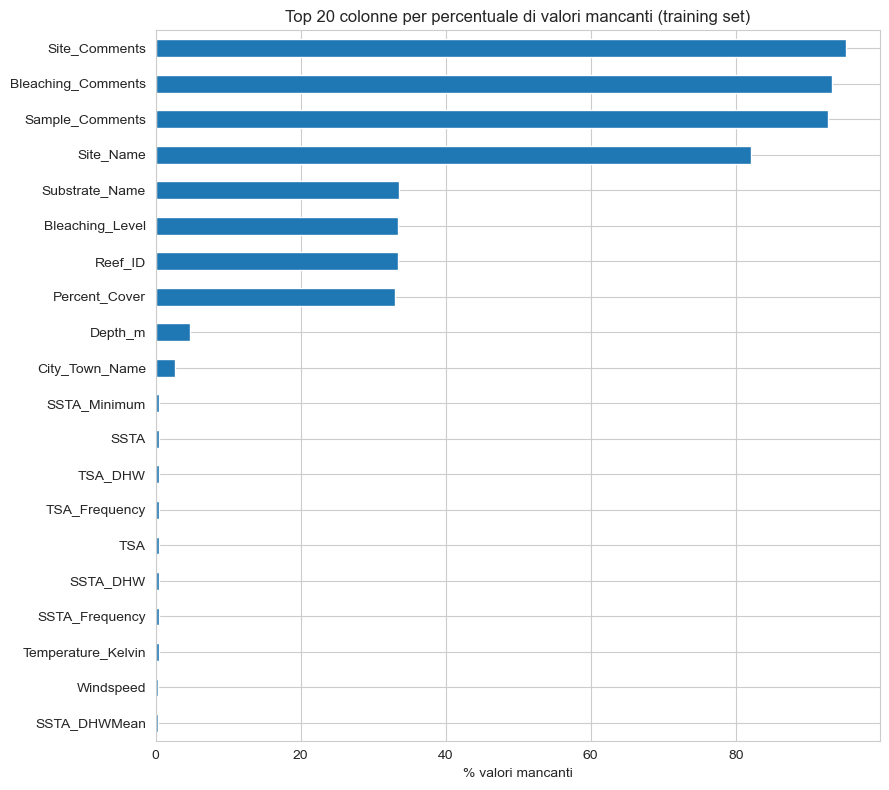

In [19]:
# Visualizziamo le colonne più problematiche
plt.figure(figsize=(9, 8))
missing_pct.head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.xlabel('% valori mancanti')
plt.title('Top 20 colonne per percentuale di valori mancanti (training set)')
plt.tight_layout()
plt.show()


L’analisi sul training set evidenzia che alcune variabili sono quasi completamente vuote. I tre campi di commento (Site_Comments, Bleaching_Comments, Sample_Comments), che richiederebbero tecniche di NLP, superano il 90% di valori mancanti, mentre Site_Name supera l’80%. Queste colonne non vengono quindi considerate adatte alla modellazione nella forma attuale.
Altre variabili presentano mancanze rilevanti ma più contenute, intorno al 30% (Substrate_Name, Bleaching_Level, Reef_ID e Percent_Cover). Per queste si cercherà di mantenere le informazioni più utili, ricorrendo all’imputazione quando appropriato.

## 5.2 Selezione delle variabili non informative

Osserviamo la cardinalità delle variabili testuali nel training set, cioè il numero di valori distinti presenti in ciascuna colonna. Le variabili con cardinalità molto elevata, in particolare gli identificativi, possono introdurre numerose categorie poco informative e rendere il modello più complesso senza migliorare la capacità di generalizzazione. Per questo motivo verranno individuate e rimosse le colonne che svolgono principalmente una funzione identificativa, insieme a quelle ridondanti o costant

In [20]:
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns

# Calcolo della cardinalità sul training set
cardinality = pd.DataFrame({
    "Valori_distinti": X_train[categorical_cols].nunique(dropna=True),
    "Percentuale_sul_training": (
        X_train[categorical_cols].nunique(dropna=True) / len(X_train) * 100
    ).round(2)
}).sort_values(by="Valori_distinti", ascending=False)

cardinality

,Valori_distinti,Percentuale_sul_training
Date,3464,16.830
Reef_ID,2468,11.990
Site_Name,1252,6.080
City_Town_Name,1152,5.600
Sample_Comments,821,3.990
Site_Comments,481,2.340
State_Island_Province_Name,380,1.850
Ecoregion_Name,105,0.510
Country_Name,87,0.420
Data_Source,9,0.040


La cardinalità mostra che diverse variabili categoriche contengono un numero molto elevato di livelli, come Reef_ID, Site_Name e le suddivisioni amministrative. Per evitare un’eccessiva frammentazione delle categorie e ridurre il rischio di overfitting, queste colonne vengono escluse dalla modellazione. Tra le variabili geografiche ad alta cardinalità viene mantenuta Ecoregion_Name, perché rappresenta una suddivisione basata su caratteristiche ecologiche e ambientali, più coerente con l’obiettivo dell’analisi rispetto ai confini amministrativi. Date viene rimossa perché l’informazione temporale è già disponibile nelle variabili giorno, mese e anno, mentre Bleaching_Level è costante e non aggiunge informazione discriminante

In [21]:
# Colonne da rimuovere, individuate sul training set
cols_to_drop = [
    # identificativi senza significato predittivo
    'Site_ID', 'Sample_ID', 'Reef_ID',
    # identificativi geografici testuali ad alta cardinalità
    'Site_Name', 'City_Town_Name',
    # testo libero  - non usabile senza NLP
    'Site_Comments', 'Sample_Comments', 'Bleaching_Comments',
    # variabile costante, non informativa
    'Bleaching_Level',
    # data completa in formato stringa, ridondante con Date_Day/Month/Year
    'Date',
    # suddivisioni amministrative meno informative rispetto a Ecoregion_Name
    'Country_Name', 'State_Island_Province_Name',
]

# Applichiamo la stessa rimozione a training, validation e test
X_train = X_train.drop(columns=cols_to_drop)
X_val = X_val.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

# Allineiamo anche il dataframe usato per l'EDA
df_train = df_train.drop(columns=cols_to_drop)

print("Shape del training dopo la rimozione:", X_train.shape)

remaining_columns = pd.DataFrame({
    "Feature rimaste": X_train.columns
})

remaining_columns


Shape del training dopo la rimozione: (20586, 49)


,Feature rimaste
0,Data_Source
1,Latitude_Degrees
2,Longitude_Degrees
3,Ocean_Name
4,Realm_Name
5,Ecoregion_Name
6,Distance_to_Shore
7,Exposure
8,Turbidity
9,Cyclone_Frequency


## 5.3 Distribuzione del target

Osserviamo il bilanciamento tra le classi sul solo target di training `y_train`.

In [22]:
# Conteggio delle classi nel training set
print("Distribuzione del target (y_train):")
print(y_train.value_counts())

print("\nDistribuzione percentuale:")
print((y_train.value_counts(normalize=True) * 100).round(1))

Distribuzione del target (y_train):
Bleaching_Occurrence
1    10460
0    10126
Name: count, dtype: int64

Distribuzione percentuale:
Bleaching_Occurrence
1   50.800
0   49.200
Name: proportion, dtype: float64


Il target di training è ben bilanciato: circa il 50,8% delle osservazioni presenta sbiancamento (10.460 casi), mentre il 49,2% non lo presenta (10.126 casi). Non emerge quindi uno sbilanciamento rilevante tra le classi, e non sono necessarie tecniche specifiche di riequilibrio

## 5.4 Statistiche descrittive

Osserviamo un riepilogo statistico delle variabili numeriche del training set.

In [23]:
stats = df_train.describe().T
stats

,count,mean,std,min,25%,50%,75%,max
Latitude_Degrees,"20,586.000",8.218,15.644,-28.464,-0.721,10.882,21.576,36.750
Longitude_Degrees,"20,586.000",27.309,104.369,-179.859,-80.088,57.347,119.779,179.950
Distance_to_Shore,"20,584.000","3,517.055","12,362.769",3.200,123.990,436.060,"2,004.490","281,663.760"
Turbidity,"20,582.000",0.075,0.060,0.000,0.042,0.057,0.085,1.284
Cyclone_Frequency,"20,586.000",52.406,7.706,19.860,47.990,51.410,56.630,105.800
Date_Day,"20,586.000",15.846,7.827,1.000,10.000,15.000,22.000,31.000
Date_Month,"20,586.000",6.808,2.910,1.000,4.000,7.000,9.000,12.000
Date_Year,"20,586.000","2,008.960",5.761,"1,983.000","2,005.000","2,009.000","2,014.000","2,020.000"
Depth_m,"19,611.000",7.000,4.201,0.000,4.000,6.000,10.000,50.300
Percent_Cover,"13,780.000",19.558,20.864,0.000,1.250,12.500,32.500,93.750


La tabella riassuntiva mette già in luce alcuni aspetti utili:

- `Percent_Bleaching` ha una **mediana pari a 0,25** ma una **media di circa 8,8**: la forte distanza tra le due indica una distribuzione molto asimmetrica, concentrata sui valori bassi.
- `Distance_to_Shore` presenta una distribuzione fortemente asimmetrica: la mediana è circa 436, mentre la media supera 3.500 e il valore massimo è molto distante dai quartili centrali. Questo suggerisce la presenza di poche osservazioni estremamente lontane dalla costa.
  
  Questi aspetti verranno approfonditi nelle sezioni successive

## 5.5 Distribuzioni delle variabili numeriche

Per rendere l'analisi più leggibile ci concentriamo su un sottoinsieme di variabili numeriche rilevanti.

In [24]:
key_vars = [
    'Percent_Bleaching', 'Distance_to_Shore', 'Turbidity',
    'Depth_m', 'Percent_Cover', 'Temperature_Mean',
    'SSTA', 'SSTA_DHW', 'TSA', 'TSA_DHW',
    'Windspeed', 'Cyclone_Frequency'
]

Calcoliamo **skewness** (asimmetria) e **kurtosis** (code) per quantificare la forma delle distribuzioni.

In [25]:
# DataFrame che conterrà i risultati
skew_kurt = pd.DataFrame(index=key_vars)

# Calcolo delle statistiche
skew_kurt['Skewness'] = df_train[key_vars].skew()
skew_kurt['Kurtosis_eccesso'] = df_train[key_vars].kurt()
skew_kurt['N_osservazioni'] = df_train[key_vars].count()

# Ordiniamo le variabili in base alla skewness
skew_kurt = skew_kurt.sort_values('Skewness', ascending=False)

skew_kurt


,Skewness,Kurtosis_eccesso,N_osservazioni
Distance_to_Shore,9.814,132.328,20584
TSA_DHW,7.107,65.594,20506
Turbidity,5.076,60.551,20582
SSTA_DHW,4.041,25.435,20506
Percent_Bleaching,2.802,7.333,20586
Depth_m,1.452,6.164,19611
Percent_Cover,1.040,0.237,13780
Cyclone_Frequency,0.635,2.885,20586
Windspeed,0.400,-0.018,20512
SSTA,0.289,2.502,20506


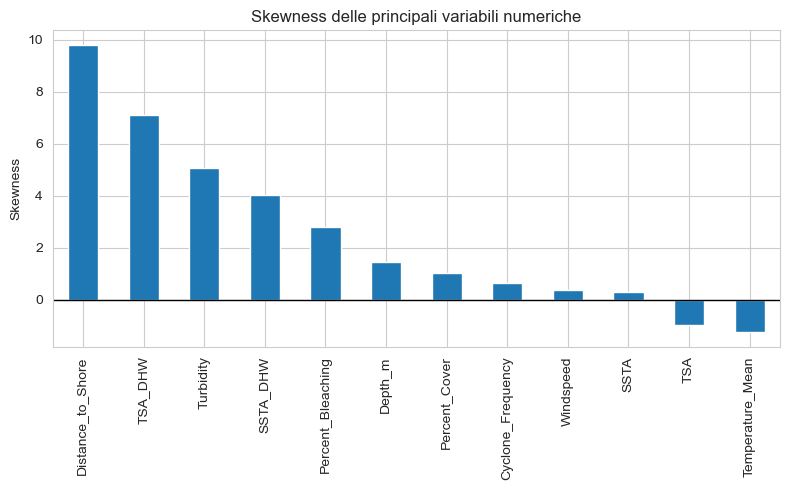

In [26]:
plt.figure(figsize=(8,5))

skew_kurt['Skewness'].plot(kind='bar')

plt.axhline(0, color='black', linewidth=1)
plt.ylabel('Skewness')
plt.title('Skewness delle principali variabili numeriche')
plt.tight_layout()
plt.show()

Molte variabili mostrano una **skewness positiva** marcata: `Distance_to_Shore` (≈ 9,8) e `TSA_DHW` (≈ 7,1) sono le più asimmetriche, seguite da `Turbidity` (≈ 5,1) e `SSTA_DHW` (≈ 4,0). Anche `Percent_Bleaching` è asimmetrica verso destra (≈ 2,8). Poche variabili risultano invece leggermente asimmetriche a sinistra, come `Temperature_Mean` e `TSA`. 
Queste forti asimmetrie andrànno considerata per i modelli sensibili alla scala.

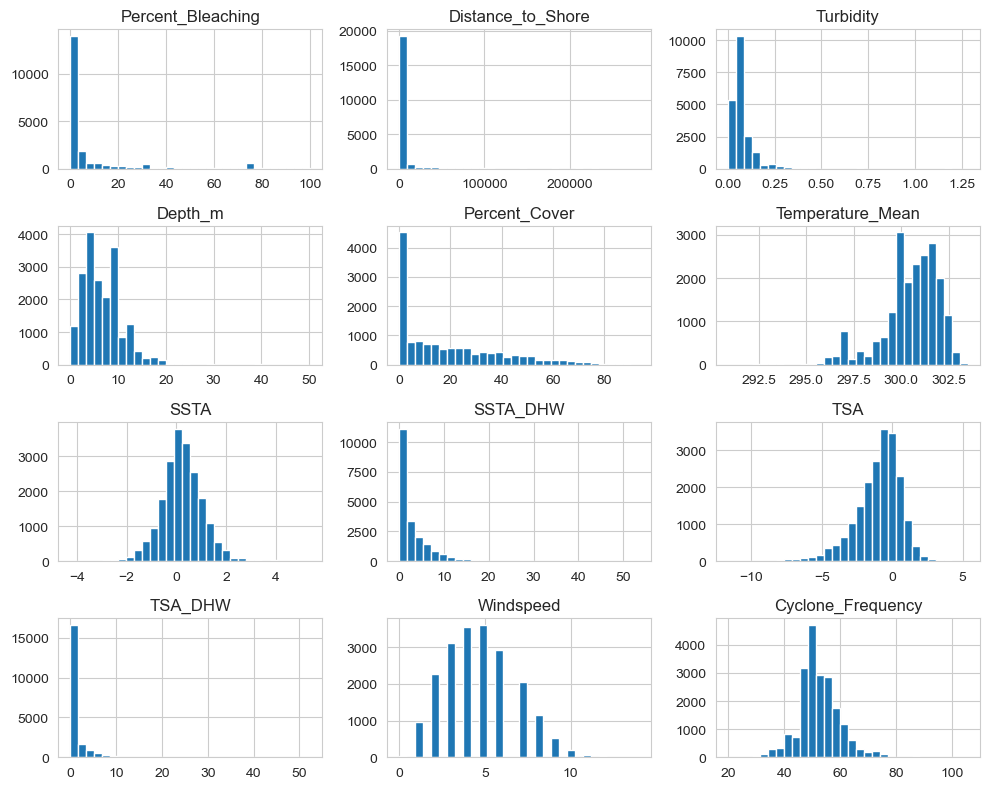

In [27]:
fig, axes = plt.subplots(4, 3, figsize=(10, 8))

axes = axes.flatten()

for ax, col in zip(axes, key_vars):
    df_train[col].hist(bins=30, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

Gli istogrammi confermano quanto emerso: la maggior parte delle variabili di stress termico è concentrata su valori bassi, con code lunghe verso destra, mentre le temperature medie mostrano distribuzioni più vicine alla simmetria. Percent_Bleaching presenta una forte concentrazione in corrispondenza dello zero, coerentemente con la mediana molto bassa.

## 5.5.1 Analisi approfondita della distribuzione di Percent_Bleaching

Percent_Bleaching viene analizzata più nel dettaglio perché è la variabile da cui deriva il target binario Bleaching_Occurrence. Dopo aver osservato la forte concentrazione in corrispondenza dello zero, approfondiamo la distribuzione dei soli valori positivi per verificare la presenza di picchi, valori ricorrenti o osservazioni estreme che potrebbero indicare particolari modalità di registrazione dei dati

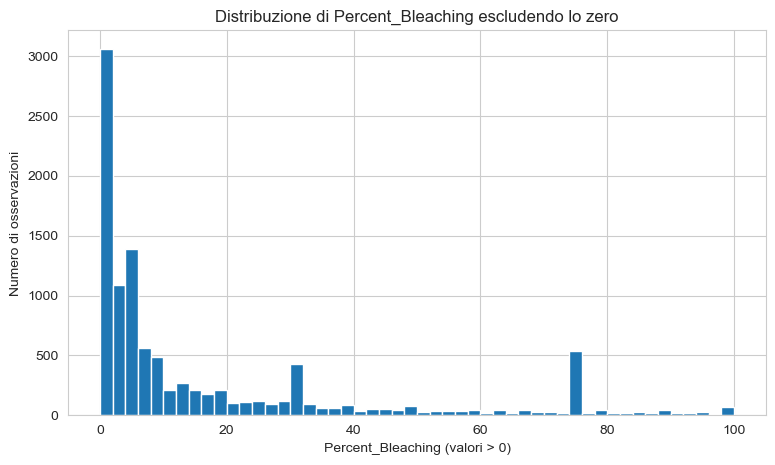

In [28]:
plt.figure(figsize=(9, 5))
df_train[df_train['Percent_Bleaching'] > 0]['Percent_Bleaching'].hist(bins=50)
plt.xlabel('Percent_Bleaching (valori > 0)')
plt.ylabel('Numero di osservazioni')
plt.title('Distribuzione di Percent_Bleaching escludendo lo zero')
plt.show()

Escludendo gli zeri, la distribuzione mostra due picchi isolati, più alti dei valori circostanti: uno intorno al 30% e uno, più marcato, intorno al 75%. Verifichiamo se corrispondono a valori esattamente ripetuti.

In [29]:
# Verifichiamo se i picchi isolati intorno al 30% e al 75% corrispondono a valori ripetuti
intervalli = [(25, 35), (70, 80)]

for minimo, massimo in intervalli:
    valori = df_train.loc[
        df_train["Percent_Bleaching"].between(minimo, massimo),
        "Percent_Bleaching"
    ]

    print(f"Valori più frequenti tra {minimo}% e {massimo}%:")
    print(valori.value_counts().head(5))
    print()

Valori più frequenti tra 25% e 35%:
Percent_Bleaching
30.500    363
25.000     59
30.000     34
33.330     30
35.000     27
Name: count, dtype: int64

Valori più frequenti tra 70% e 80%:
Percent_Bleaching
75.000    523
80.000     32
70.000     24
72.500      4
72.000      4
Name: count, dtype: int64



Il controllo conferma che si tratta di valori ripetuti molto più spesso dei loro vicini: **75,0% compare 523 volte** (contro le 24 di 70 e le 32 di 80), mentre nell'intorno del 30% spicca il valore **30,5% con 363 occorrenze**. Prima di interpretarli, verifichiamo se lo stesso fenomeno riguardi anche altri valori "tondi" della scala.

In [30]:
valori_da_approfondire = [30.5, 75]

subset_valori = df_train[
    df_train["Percent_Bleaching"].isin(valori_da_approfondire)
]

def tre_valori_piu_frequenti(x):
    return x.value_counts().head(3)

print("Distribuzione per anno:")
print(
    subset_valori.groupby("Percent_Bleaching")["Date_Year"]
    .apply(tre_valori_piu_frequenti)
)

print("\nDistribuzione geografica:")
print(
    subset_valori.groupby("Percent_Bleaching")["Ecoregion_Name"]
    .apply(tre_valori_piu_frequenti)
)

print("\nCondizioni ambientali medie:")
print(
    subset_valori.groupby("Percent_Bleaching")[
        ["Temperature_Mean", "SSTA_DHW", "Depth_m"]
    ].mean()
)

Distribuzione per anno:
Percent_Bleaching      
30.500             1998    123
                   2002     48
                   2016     34
75.000             1998    221
                   2002     76
                   2005     48
Name: Date_Year, dtype: int64

Distribuzione geografica:
Percent_Bleaching                                         
30.500             Central and northern Great Barrier Reef     54
                   North Ryukyu Islands Japan                  50
                   South Ryukyu Islands Japan                  43
75.000             Central and northern Great Barrier Reef    107
                   Southern Great Barrier Reef                 49
                   South Ryukyu Islands Japan                  36
Name: Ecoregion_Name, dtype: int64

Condizioni ambientali medie:
                   Temperature_Mean  SSTA_DHW  Depth_m
Percent_Bleaching                                     
30.500                      299.393     6.336    7.497
75.000                  

In [31]:
 #Approfondiamo nello specifico il caso del 75%, il più numeroso e meglio definito
subset_75 = df_train[df_train['Percent_Bleaching'] == 75]

print("Anni principali (75%):")
print(subset_75['Date_Year'].value_counts().head(10))

print("\nEcoRegioni principali (75%):")
print(subset_75['Ecoregion_Name'].value_counts().head(10))

Anni principali (75%):
Date_Year
1998    221
2002     76
2005     48
2016     36
2009     20
2000     16
2007     15
2013     13
2010     10
2008      9
Name: count, dtype: int64

EcoRegioni principali (75%):
Ecoregion_Name
Central and northern Great Barrier Reef       107
Southern Great Barrier Reef                    49
South Ryukyu Islands Japan                     36
Belize and west Caribbean                      33
Bahamas and Florida Keys                       29
North Ryukyu Islands Japan                     20
Society Islands French Polynesia               18
Hispaniola Puerto Rico and Lesser Antilles     15
Fiji                                           13
Kenya and Tanzania coast                       12
Name: count, dtype: int64


L’approfondimento sui valori ricorrenti di Percent_Bleaching mostra che entrambi i picchi, pari a 30,5% e 75%, non sono limitati a un singolo anno o a una sola area geografica. Per entrambi emerge una forte concentrazione nel 1998, anno caratterizzato dall’intenso episodio di El Niño del 1997–1998, associato a uno dei più grandi eventi globali di sbiancamento mai registrati.

Anche la distribuzione geografica coinvolge più ecoregioni, in particolare diverse aree della Grande Barriera Corallina e del Giappone meridionale. I picchi non sembrano quindi riconducibili a una singola fonte locale. Pertanto, questi valori vengono mantenuti nell’analisi

## 5.6 Analisi degli outlier

In [32]:
for col in ["Distance_to_Shore", "Turbidity"]:
    print(f"\n--- {col} ---")
    print(df_train[col].describe())
    print("99° percentile:", df_train[col].quantile(0.99))
    print("Top 10 valori più alti:")
    print(df_train[col].nlargest(10))


--- Distance_to_Shore ---
count    20,584.000
mean      3,517.055
std      12,362.769
min           3.200
25%         123.990
50%         436.060
75%       2,004.490
max     281,663.760
Name: Distance_to_Shore, dtype: float64
99° percentile: 45876.84
Top 10 valori più alti:
3550   281,663.760
3554   238,898.440
3555   233,763.640
5310   230,192.640
3544   228,892.500
3543   226,662.830
5308   225,582.280
3546   219,133.240
5307   218,784.900
5306   215,583.400
Name: Distance_to_Shore, dtype: float64

--- Turbidity ---
count   20,582.000
mean         0.075
std          0.060
min          0.000
25%          0.042
50%          0.057
75%          0.085
max          1.284
Name: Turbidity, dtype: float64
99° percentile: 0.2899
Top 10 valori più alti:
3527    1.284
17881   1.163
17882   1.163
17883   1.163
17884   1.163
17885   1.163
17886   1.163
24895   1.163
24896   1.163
4098    0.979
Name: Turbidity, dtype: float64


Entrambe le variabili mostrano valori estremi molto distanti dal resto della distribuzione. Per capire se si tratta di osservazioni plausibili o di possibili anomalie, ne approfondiamo il contesto geografico e la frequenza

In [33]:
cols_da_mostrare = ["Latitude_Degrees", "Longitude_Degrees", "Date_Year", "Ecoregion_Name"]

print("=== Distance_to_Shore: 10 valori più alti ===")
top_dist = df_train["Distance_to_Shore"].nlargest(10).index
print(df_train.loc[top_dist, ["Distance_to_Shore"] + cols_da_mostrare])


=== Distance_to_Shore: 10 valori più alti ===
      Distance_to_Shore  Latitude_Degrees  Longitude_Degrees  Date_Year                                     Ecoregion_Name
3550        281,663.760           -21.084            152.284       2002  Pompey and Swain Reefs south-east Great Barrie...
3554        238,898.440           -21.003            152.474       2002  Pompey and Swain Reefs south-east Great Barrie...
3555        233,763.640           -20.985            152.395       2002  Pompey and Swain Reefs south-east Great Barrie...
5310        230,192.640           -21.178            152.517       2002  Pompey and Swain Reefs south-east Great Barrie...
3544        228,892.500           -21.203            152.523       2002  Pompey and Swain Reefs south-east Great Barrie...
3543        226,662.830           -21.207            152.499       2002  Pompey and Swain Reefs south-east Great Barrie...
5308        225,582.280           -21.230            152.504       2002  Pompey and Swain Ree

In [34]:
print("=== Turbidity: 10 valori più alti ===")
top_turb = df_train["Turbidity"].nlargest(10).index
print(df_train.loc[top_turb, ["Turbidity"] + cols_da_mostrare])

=== Turbidity: 10 valori più alti ===
       Turbidity  Latitude_Degrees  Longitude_Degrees  Date_Year                            Ecoregion_Name
3527       1.284             9.012            -81.821       2002                 Belize and west Caribbean
17881      1.163            26.163             56.355       2009                              Gulf of Oman
17882      1.163            26.163             56.355       2009                              Gulf of Oman
17883      1.163            26.163             56.355       2009                              Gulf of Oman
17884      1.163            26.163             56.355       2009                              Gulf of Oman
17885      1.163            26.163             56.355       2010                              Gulf of Oman
17886      1.163            26.163             56.355       2010                              Gulf of Oman
24895      1.163            26.163             56.355       2010                              Gulf of Oman

L’analisi dei valori estremi mostra che essi sono associati a specifici contesti geografici. Per Distance_to_Shore, i valori più elevati provengono dalle Pompey e Swain Reefs, aree oceaniche remote della Grande Barriera Corallina, e risultano coerenti con la loro localizzazione.

Per Turbidity, molti dei valori più alti condividono le stesse coordinate nel Golfo dell’Oman e compaiono sia nello stesso anno sia in anni diversi. Poiché in precedenza non sono state individuate righe completamente duplicate, queste osservazioni differiscono necessariamente per almeno un’altra variabile e possono quindi rappresentare campionamenti distinti effettuati nello stesso sito.

Nel complesso, i valori estremi risultano compatibili con la struttura geografica e temporale del dataset e vengono mantenuti nell’analisi

## 5.7 Analisi delle variabili asimmetriche

Le variabili molto asimmetriche possono penalizzare i modelli lineari. Prima di prevedere una trasformazione logaritmica verifichiamo che assumano solo valori non negativi.

In [35]:
skewed_cols = [
    "Distance_to_Shore",
    "Turbidity",
    "SSTA_DHW",
    "Percent_Cover"
]

for col in skewed_cols:
    print(f"{col}: minimo = {df_train[col].min()}")

Distance_to_Shore: minimo = 3.2
Turbidity: minimo = 0.0
SSTA_DHW: minimo = 0.0
Percent_Cover: minimo = 0.0


I minimi sono tutti ≥ 0, quindi una trasformazione `log1p` è applicabile. Ne valutiamo visivamente l'effetto su `Distance_to_Shore`.

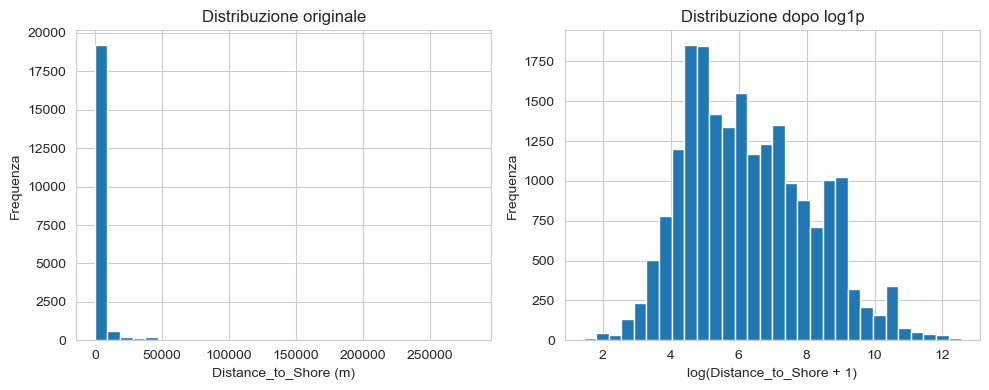

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(df_train["Distance_to_Shore"], bins=30)
axes[0].set_title("Distribuzione originale")
axes[0].set_xlabel("Distance_to_Shore (m)")
axes[0].set_ylabel("Frequenza")

# log calcolato solo per il grafico, senza salvarlo nel dataset
axes[1].hist(np.log1p(df_train["Distance_to_Shore"]), bins=30)
axes[1].set_title("Distribuzione dopo log1p")
axes[1].set_xlabel("log(Distance_to_Shore + 1)")
axes[1].set_ylabel("Frequenza")

plt.tight_layout()
plt.show()

Il confronto conferma che la trasformazione logaritmica ridurrebbe sensibilmente l'asimmetria, rendendo la distribuzione molto più simmetrica. Nella pipeline utilizzeremo una trasformazione della stessa famiglia (Yeo-Johnson) per i modelli sensibili alla scala.

## 5.8 Controllo della qualità dei dati

Verifichiamo che le variabili con un intervallo di validità noto non contengano valori impossibili.

In [37]:
valid_ranges = {
    "Percent_Bleaching": (0, 100),
    "Percent_Cover": (0, 100),
    "Latitude_Degrees": (-90, 90),
    "Longitude_Degrees": (-180, 180),
    "Depth_m": (0, None),
    "Distance_to_Shore": (0, None)
}

for col, (min_val, max_val) in valid_ranges.items():
    invalid = df_train[col] < min_val

    if max_val is not None:
        invalid = invalid | (df_train[col] > max_val)

    print(f"{col}: {invalid.sum()} valori fuori intervallo")

Percent_Bleaching: 0 valori fuori intervallo
Percent_Cover: 0 valori fuori intervallo
Latitude_Degrees: 0 valori fuori intervallo
Longitude_Degrees: 0 valori fuori intervallo
Depth_m: 0 valori fuori intervallo
Distance_to_Shore: 0 valori fuori intervallo


Nessuna variabile presenta valori fuori intervallo: percentuali comprese tra 0 e 100, coordinate valide e profondità/distanze non negative. La qualità strutturale dei dati è confermata.

## 5.9 Controllo delle variabili categoriche

In [38]:
categorical_cols = X_train.select_dtypes(include="object").columns
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print("Numero di categorie:", df_train[col].nunique())
    print("Valori mancanti:", df_train[col].isna().sum())
    print(df_train[col].value_counts(dropna=False).head(10))


--- Data_Source ---
Numero di categorie: 9
Valori mancanti: 0
Data_Source
Reef_Check    13706
Donner         2773
FRRP           1766
AGRRA          1763
Kumagai         422
McClanahan      125
Safaie           27
Nuryana           2
Setiawan          2
Name: count, dtype: int64

--- Ocean_Name ---
Numero di categorie: 5
Valori mancanti: 0
Ocean_Name
Pacific         10745
Atlantic         7894
Indian           1204
Red Sea           587
Arabian Gulf      156
Name: count, dtype: int64

--- Realm_Name ---
Numero di categorie: 8
Valori mancanti: 0
Realm_Name
Central Indo-Pacific           8959
Tropical Atlantic              7887
Western Indo-Pacific           1866
Eastern Indo-Pacific           1070
Temperate Australasia           428
Temperate Northern Pacific      300
Tropical Eastern Pacific         69
Temperate Northern Atlantic       7
Name: count, dtype: int64

--- Ecoregion_Name ---
Numero di categorie: 105
Valori mancanti: 1
Ecoregion_Name
Bahamas and Florida Keys                

Le variabili categoriche presentano cardinalità molto diversa: Ecoregion_Name è la più ricca, con 105 categorie, mentre Ocean_Name, Realm_Name, Data_Source e Substrate_Name hanno un numero più contenuto di livelli.Substrate_Name presenta numerosi valori mancanti. Nelle analisi successive approfondiremo singolarmente le variabili che richiedono una gestione specifica.

## 5.10 Analisi delle correlazioni tra le variabili numeriche

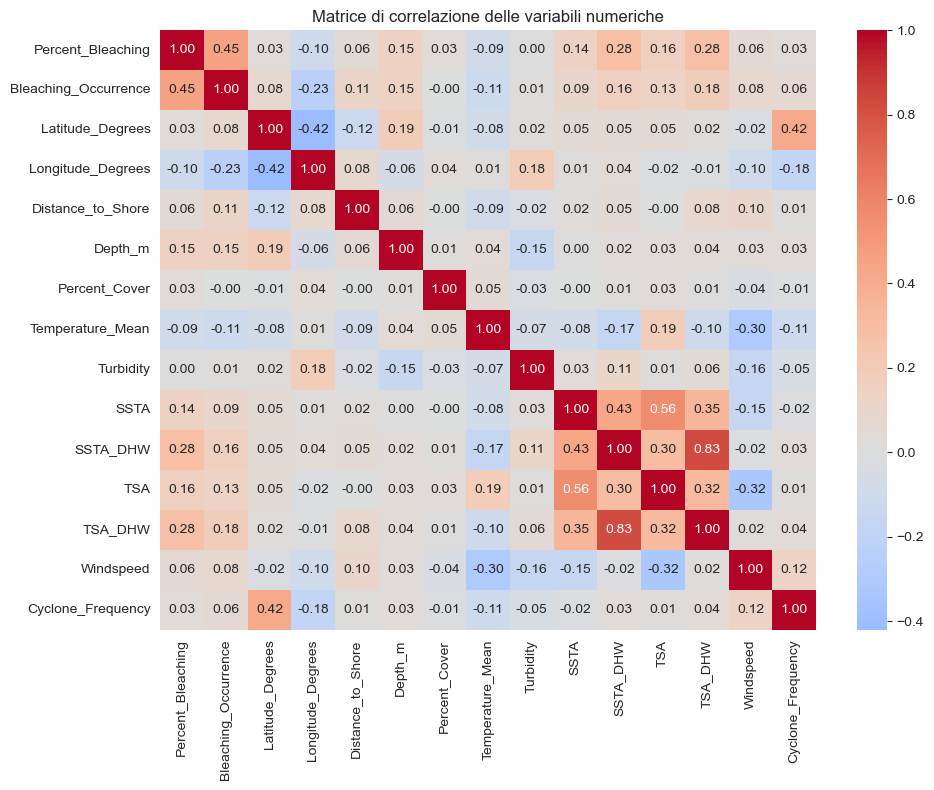

In [39]:
# Variabili numeriche da includere nella correlazione
corr_cols = [
    "Percent_Bleaching",
    "Bleaching_Occurrence",
    "Latitude_Degrees",
    "Longitude_Degrees",
    "Distance_to_Shore",
    "Depth_m",
    "Percent_Cover",
    "Temperature_Mean",
    "Turbidity",
    "SSTA",
    "SSTA_DHW",
    "TSA",
    "TSA_DHW",
    "Windspeed",
    "Cyclone_Frequency",
    
]

# Calcolo della matrice di correlazione
corr_matrix = df_train[corr_cols].corr()

# Visualizzazione
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matrice di correlazione delle variabili numeriche")
plt.tight_layout()
plt.show()

### Interpretazione della matrice di correlazione

La matrice evidenzia alcune correlazioni elevate tra le variabili che descrivono fenomeni ambientali simili, in particolare tra gli indicatori legati alla temperatura e allo stress termico. Questo suggerisce la presenza di informazioni parzialmente sovrapposte tra alcune feature. Si osserva inoltre, come atteso, una forte correlazione tra Percent_Bleaching e Bleaching_Occurrence, poiché il target binario è stato ricavato direttamente dalla percentuale di bleaching. Per analizzare più chiaramente il rapporto tra le singole variabili ambientali e il fenomeno, nella sezione successiva consideriamo separatamente le loro correlazioni con Percent_Bleaching.

## 5.11 Relazione tra il bleaching e alcune variabili ambientali
Per approfondire il legame tra le condizioni ambientali e il fenomeno osservato, analizziamo la correlazione con Percent_Bleaching. Questa variabile rappresenta la percentuale di corallo sbiancato rilevata durante i campionamenti ed è direttamente collegata a Bleaching_Occurrence, che è stato ricavato dalla sua trasformazione in forma binaria. Utilizzare la percentuale originale permette però di conservare più informazione rispetto al solo valore 0/1 e di valutare non soltanto la presenza del bleaching, ma anche la sua intensità

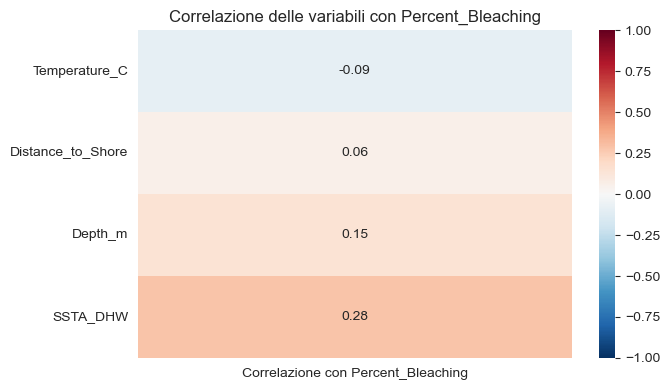

In [40]:
# Creazione temporanea della temperatura in Celsius solo per la visualizzazione
df_corr = df_train.copy()

df_corr["Temperature_C"] = df_corr["Temperature_Mean"] - 273.15

cols = ["SSTA_DHW", "Temperature_C", "Depth_m", "Distance_to_Shore"]

corr = (
    df_corr[cols + ["Percent_Bleaching"]]
    .corr()["Percent_Bleaching"]
    .drop("Percent_Bleaching")
    .sort_values()
)

fig, ax = plt.subplots(figsize=(7, 4))

sns.heatmap(
    corr.to_frame("Correlazione con Percent_Bleaching"),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax
)

ax.set_title("Correlazione delle variabili con Percent_Bleaching")

plt.tight_layout()
plt.show()

La figura riporta la correlazione di ciascuna variabile ambientale con la percentuale di bleaching. Lo **stress termico accumulato (`SSTA_DHW`)** è la variabile più associata al fenomeno (correlazione ≈ **0,28**), seguito dalla profondità (≈ 0,15). La temperatura media e la distanza dalla costa hanno correlazioni prossime allo zero (rispettivamente ≈ −0,09 e 0,06), segno di scarso potere informativo se considerate singolarmente. Osserviamo la relazione tra stress termico e bleaching lungo l'intero intervallo di valori.

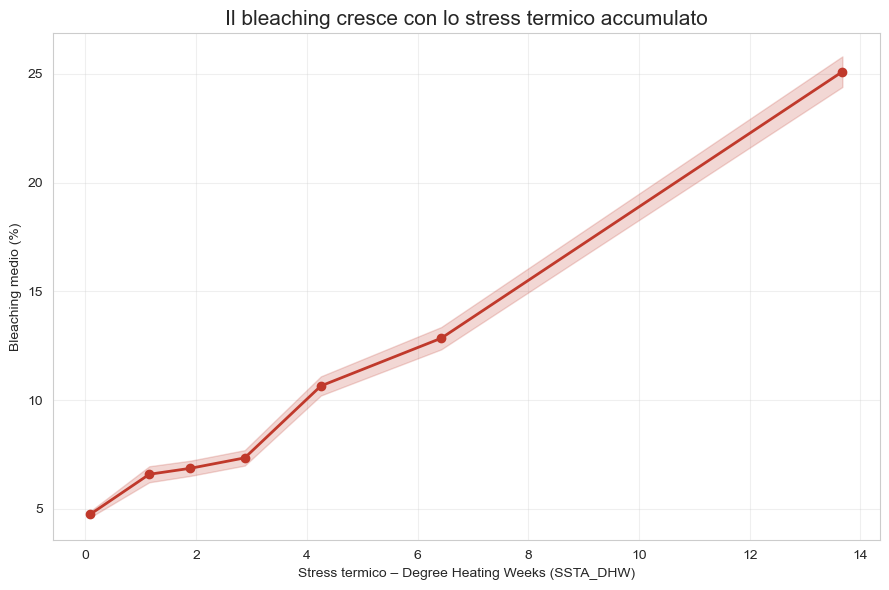

In [41]:
temp = df_train[["SSTA_DHW", "Percent_Bleaching"]].dropna().copy()
temp["bin"] = pd.qcut(temp["SSTA_DHW"], q=10, labels=False, duplicates="drop")

summary = (
    temp.groupby("bin", observed=True)
    .agg(
        x=("SSTA_DHW", "mean"),
        y=("Percent_Bleaching", "mean"),
        se=("Percent_Bleaching", "sem"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(summary["x"], summary["y"], marker="o", color="#c0392b", linewidth=2)
ax.fill_between(summary["x"], summary["y"] - summary["se"],
                summary["y"] + summary["se"], alpha=0.2, color="#c0392b")

ax.set_title("Il bleaching cresce con lo stress termico accumulato", fontsize=15)
ax.set_xlabel("Stress termico – Degree Heating Weeks (SSTA_DHW)")
ax.set_ylabel("Bleaching medio (%)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Il grafico conferma quanto suggerito dalla correlazione: il bleaching medio **cresce in modo netto e progressivo** all'aumentare dello stress termico accumulato, passando da circa il **5%** nelle osservazioni con stress prossimo allo zero a oltre il **25%** ai valori più elevati. La banda di incertezza resta contenuta lungo tutta la curva, a indicare una relazione stabile. Questo risultato è coerente con le conoscenze biologiche: lo sbiancamento è innescato soprattutto dall'accumulo di calore rispetto alle condizioni abituali.

# **6. Preparazione delle feature per il Machine Learning**

Prepariamo le feature per i modelli. Le trasformazioni che dipendono dalle statistiche dei dati (imputazione, scaling, power transform, selezione delle ecoregioni più frequenti) sono stimate **solo sul training set** e applicate agli altri insiemi tramite pipeline, così da non introdurre alcun leakage.

## 6.1 Suddivisione delle feature numeriche e categoriche

Separiamo le feature per tipo, poiché richiedono trasformazioni differenti.

In [42]:
num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numero di feature numeriche:", len(num_cols))
print("Numero di feature categoriche:", len(cat_cols))
print(cat_cols)

Numero di feature numeriche: 43
Numero di feature categoriche: 6
['Data_Source', 'Ocean_Name', 'Realm_Name', 'Ecoregion_Name', 'Exposure', 'Substrate_Name']


In [43]:
for col in cat_cols:
    print(f"{col}: {X_train[col].nunique()} categorie")

Data_Source: 9 categorie
Ocean_Name: 5 categorie
Realm_Name: 8 categorie
Ecoregion_Name: 105 categorie
Exposure: 3 categorie
Substrate_Name: 3 categorie


### Gestione della variabile `Ecoregion_Name` ad alta cardinalità

`Ecoregion_Name` ha molte categorie: un one-hot encoding completo genererebbe un numero eccessivo di colonne, molte con pochissime osservazioni. Valutiamo la copertura cumulata delle ecoregioni **nel training set** per decidere quante mantenerne.

In [44]:
ecoregion_counts = X_train["Ecoregion_Name"].value_counts()
coverage = ecoregion_counts.cumsum() / ecoregion_counts.sum() * 100

for n in [10, 20, 30, 40, 50, 60]:
    print(f"Top {n} ecoregioni coprono il {coverage.iloc[n-1]:.1f}% delle osservazioni")

Top 10 ecoregioni coprono il 60.8% delle osservazioni
Top 20 ecoregioni coprono il 81.4% delle osservazioni
Top 30 ecoregioni coprono il 90.1% delle osservazioni
Top 40 ecoregioni coprono il 94.7% delle osservazioni
Top 50 ecoregioni coprono il 97.0% delle osservazioni
Top 60 ecoregioni coprono il 98.5% delle osservazioni


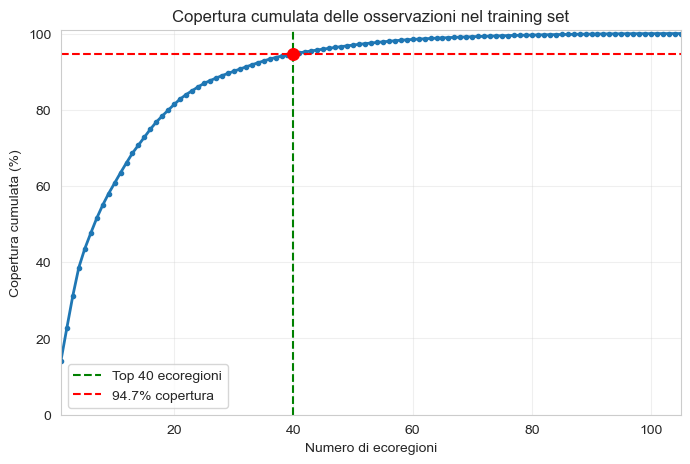

Top 40 ecoregioni: 94.7%


In [45]:
# Distribuzione delle ecoregioni nel training set
ecoregion_counts = X_train["Ecoregion_Name"].value_counts()

# Copertura cumulata (%)
coverage = ecoregion_counts.cumsum() / ecoregion_counts.sum() * 100

N = 40

plt.figure(figsize=(8,5))

# Disegna la curva
plt.plot(
    range(1, len(coverage) + 1),
    coverage.values,
    marker="o",
    markersize=3,
    linewidth=2
)

# Evidenzia la scelta
plt.axvline(N, color="green", linestyle="--", label=f"Top {N} ecoregioni")
plt.axhline(coverage.iloc[N-1], color="red", linestyle="--",
            label=f"{coverage.iloc[N-1]:.1f}% copertura")

plt.scatter(N, coverage.iloc[N-1], color="red", s=70, zorder=5)

plt.title("Copertura cumulata delle osservazioni nel training set")
plt.xlabel("Numero di ecoregioni")
plt.ylabel("Copertura cumulata (%)")


plt.xlim(1, len(coverage))
plt.ylim(0, 101)

plt.grid(alpha=0.3)
plt.legend()
plt.show()

print(f"Top {N} ecoregioni: {coverage.iloc[N-1]:.1f}%")

Le prime **40 ecoregioni** coprono circa il **94,7%** delle osservazioni del training set. Manteniamo quindi le 40 più frequenti e raggruppiamo le restanti (≈ 5,3%) in un'unica categoria `"Other"`, riducendo la dimensionalità senza perdere informazione rilevante. La soglia è calcolata solo sul training e applicata agli altri insiemi.

In [46]:
# Le prime 40 ecoregioni coprono circa il 94.7% delle osservazioni nel training set
# (verificato sopra con il controllo di copertura cumulata); le restanti ~5.3%
# vengono raggruppate in un'unica categoria "Other"
top_ecoregions = ecoregion_counts.head(40).index

for df_split in [X_train, X_val, X_test]:
    df_split["Ecoregion_Name"] = df_split["Ecoregion_Name"].where(
        df_split["Ecoregion_Name"].isin(top_ecoregions),
        "Other"
    )

print("Categorie di Ecoregion_Name dopo il raggruppamento:", X_train["Ecoregion_Name"].nunique())

Categorie di Ecoregion_Name dopo il raggruppamento: 41


In [47]:
# Variabili categoriche dopo il preprocessing
cat_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Variabili categoriche rimanenti:\n")

for col in cat_cols:
    print(f"- {col}: {X_train[col].nunique()} categorie")



Variabili categoriche rimanenti:

- Data_Source: 9 categorie
- Ocean_Name: 5 categorie
- Realm_Name: 8 categorie
- Ecoregion_Name: 41 categorie
- Exposure: 3 categorie
- Substrate_Name: 3 categorie


### Valutazione della variabile *Data_Source*

Verifichiamo il legame tra la fonte dei dati e il target, per capire se `Data_Source` sia una variabile realmente predittiva o piuttosto un artefatto del processo di raccolta.

In [48]:
source_bleaching = (
    pd.crosstab(
        X_train["Data_Source"],
        y_train,
        normalize="index"
    )
    .rename(columns={0: "No bleaching", 1: "Bleaching"})
    * 100
).round(1)

display(source_bleaching)

Bleaching_Occurrence,No bleaching,Bleaching
Data_Source,,
AGRRA,37.000,63.000
Donner,0.000,100.000
FRRP,8.400,91.600
Kumagai,51.400,48.600
McClanahan,0.800,99.200
Nuryana,0.000,100.000
Reef_Check,66.400,33.600
Safaie,3.700,96.300
Setiawan,0.000,100.000


Il tasso di bleaching varia in modo estremo tra le fonti: alcune (come *Donner*, *McClanahan*, *Setiawan*) riportano quasi solo casi di sbiancamento, altre (come *Reef_Check*) prevalentemente assenza. Questo indica che `Data_Source` riflette il **protocollo di campionamento** più che una reale condizione ambientale: usarla darebbe al modello un'informazione non generalizzabile a nuovi dati. La rimuoviamo.

In [49]:
for df_split in [X_train, X_val, X_test]:
    df_split.drop(columns="Data_Source", inplace=True)

# Aggiornamento delle variabili categoriche
cat_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Variabili categoriche rimanenti:", cat_cols)

Variabili categoriche rimanenti: ['Ocean_Name', 'Realm_Name', 'Ecoregion_Name', 'Exposure', 'Substrate_Name']


### Valutazione della variabile *Substrate_Name*

`Substrate_Name` presenta molti valori mancanti; verifichiamo il suo legame con il target prima di decidere.

In [50]:
pd.crosstab(
    X_train["Substrate_Name"],
    y_train,
    normalize="index",
    dropna=False
).round(3)

Bleaching_Occurrence,0,1
Substrate_Name,,
Fleshy Seaweed,0.827,0.173
Hard Coral,0.665,0.335
Nutrient Indicator Algae,0.661,0.339
NaN,0.150,0.850


In [51]:
for df_split in [X_train, X_val, X_test]:
    df_split.drop(columns="Substrate_Name", inplace=True)

cat_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(cat_cols)

['Ocean_Name', 'Realm_Name', 'Ecoregion_Name', 'Exposure']


### Controllo delle variabili numeriche

Controlliamo valori mancanti e variabili costanti tra le feature numeriche.

In [52]:
# Selezione delle variabili numeriche
num_train = X_train.select_dtypes(include="number")

# Controllo dei valori mancanti
missing_num = num_train.isna().sum().sort_values(ascending=False)

print("=== Valori mancanti ===")
display(missing_num.to_frame("Missing values"))

# Individuazione delle variabili costanti
constant_num = num_train.columns[num_train.nunique() <= 1]

print("\n=== Variabili costanti ===")
print(list(constant_num))



=== Valori mancanti ===


,Missing values
Percent_Cover,6806
Depth_m,975
SSTA_Minimum,94
SSTA_DHW,80
SSTA_Frequency,80
TSA_DHW,80
TSA_Frequency,80
Temperature_Kelvin,80
TSA,80
SSTA,80



=== Variabili costanti ===
['SSTA_Mean']


Dal controllo emerge che `SSTA_Mean` è costante sul training set e quindi non informativa. La variabile viene pertanto rimossa. Le mancanze residue verranno gestite tramite imputazione all’interno della pipeline.

In [53]:
# Rimozione delle variabili non informative:
cols_to_remove = ["SSTA_Mean"]

X_train = X_train.drop(columns=cols_to_remove)
X_val   = X_val.drop(columns=cols_to_remove)
X_test  = X_test.drop(columns=cols_to_remove)

# Aggiornamento delle liste di feature
num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()
print("Feature numeriche finali:", len(num_cols))
print("Feature categoriche finali:", len(cat_cols))

Feature numeriche finali: 42
Feature categoriche finali: 4


### Selezione finale delle feature

Aggiorniamo le liste di feature dopo le rimozioni.

In [54]:
# Selezione aggiornata delle variabili numeriche
num_cols = X_train.select_dtypes(include="number").columns.tolist()
# Aggiornamento finale delle liste delle feature

num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(include="object").columns.tolist()

print("Feature numeriche:", len(num_cols))
print("Feature categoriche:", len(cat_cols))

Feature numeriche: 42
Feature categoriche: 4


## 6.2 Pipeline di preprocessing

Definiamo due pipeline di preprocessing: una **con scaling** (imputazione + Yeo-Johnson standardizzato) per i modelli sensibili alla scala, e una **senza scaling** (sola imputazione) per i modelli ad albero. Le variabili categoriche vengono codificate con one-hot. Tutti i trasformatori vengono stimati esclusivamente sul training set all'interno delle pipeline.

In [55]:
# Preprocessing numerico per modelli sensibili alla scala
numeric_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("power", PowerTransformer(
        method="yeo-johnson",
        standardize=True
    ))
])

# Preprocessing numerico per modelli ad albero
numeric_unscaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Preprocessing per modelli sensibili alla scala
# (es. regressione logistica, SVM, KNN)
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_scaled, num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# Preprocessing per modelli ad albero
# (es. Decision Tree, Random Forest)
preprocessor_unscaled = ColumnTransformer(
    transformers=[
        ("num", numeric_unscaled, num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# **7. Modelli di classificazione**

Confrontiamo tre modelli: Logistic Regression, Decision Tree e Random Forest, ciascuno con la pipeline di preprocessing appropriata.

In [56]:
# Logistic Regression
log_reg = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced"))
])

# Decision Tree (modello ad albero)
tree = Pipeline([
    ("preprocessor", preprocessor_unscaled),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

# Random Forest (ensemble di alberi)
forest = Pipeline([
    ("preprocessor", preprocessor_unscaled),
    ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1))
])

## 7.1 Addestramento dei modelli

Addestriamo i tre modelli sul training set.

In [57]:
log_reg.fit(X_train, y_train)
tree.fit(X_train, y_train)
forest.fit(X_train, y_train)

print("Addestramento completato.")

Addestramento completato.


## 7.2 Valutazione e confronto sul validation set

Confrontiamo i modelli sul validation set usando più metriche.

In [58]:
# modelli da confrontare

models = {
    "Logistic Regression": log_reg,
    "Decision Tree": tree,
    "Random Forest": forest
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1-score": f1_score(y_val, y_pred),
        "ROC-AUC": roc_auc_score(y_val, y_prob)
    })

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).round(3)
results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,Random Forest,0.746,0.762,0.682,0.720,0.821
0,Logistic Regression,0.713,0.714,0.668,0.691,0.794
1,Decision Tree,0.679,0.656,0.698,0.676,0.680


Sul validation set la **Random Forest** ottiene i risultati migliori, con la ROC-AUC più alta (**0,821**) e il miglior compromesso complessivo tra le metriche. La Logistic Regression la segue (AUC 0,792), mentre il Decision Tree singolo è nettamente inferiore (AUC 0,679). Proseguiamo l'analisi con la Random Forest.

## 7.3 Analisi del modello selezionato (Random Forest)

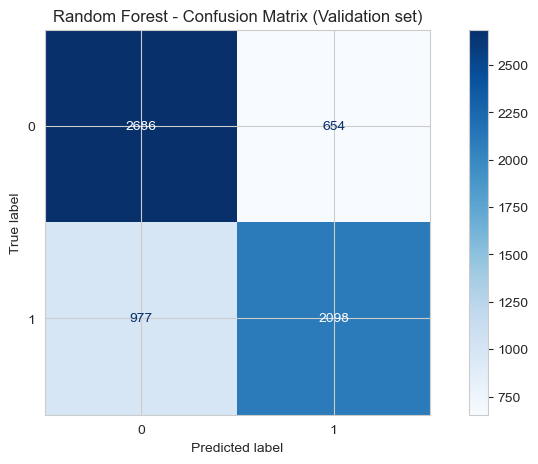

In [59]:
# Predizioni della Random Forest sul validation set
y_val_pred = forest.predict(X_val)

# Matrice di confusione
ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred,
    cmap="Blues"
)

plt.title("Random Forest - Confusion Matrix (Validation set)")
plt.show()

Con la soglia predefinita di 0,50 il modello classifica correttamente gran parte delle osservazioni, ma perde una quota non trascurabile di eventi reali di bleaching (falsi negativi). Nel contesto del monitoraggio dei reef, mancare un evento reale è più costoso di un falso allarme: valutiamo quindi soglie decisionali alternative.

### Scelta della soglia decisionale

In [60]:
# Probabilità previste dalla Random Forest per la classe positiva
y_val_prob = forest.predict_proba(X_val)[:, 1]

# Soglie da confrontare
thresholds = [0.50, 0.45, 0.40, 0.35]

threshold_results = []

for threshold in thresholds:

    # Conversione delle probabilità in classi usando la soglia scelta
    y_val_pred_threshold = (y_val_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_val, y_val_pred_threshold),
        "Precision": precision_score(y_val, y_val_pred_threshold),
        "Recall": recall_score(y_val, y_val_pred_threshold),
        "F1-score": f1_score(y_val, y_val_pred_threshold)
    })

threshold_results_df = pd.DataFrame(threshold_results).round(3)

display(threshold_results_df)

,Threshold,Accuracy,Precision,Recall,F1-score
0,0.500,0.745,0.754,0.693,0.722
1,0.450,0.732,0.705,0.757,0.730
2,0.400,0.712,0.661,0.820,0.732
3,0.350,0.682,0.620,0.871,0.724


L'analisi evidenzia il tipico compromesso precision–recall: abbassando la soglia la Recall aumenta mentre la Precision diminuisce. Poiché privilegiamo la capacità di individuare gli eventi reali, adottiamo la soglia **0,40**, che porta la Recall a **0,81** (contro 0,70 della soglia 0,50), al prezzo di una Precision più bassa (≈ 0,66), che accettiamo consapevolmente.

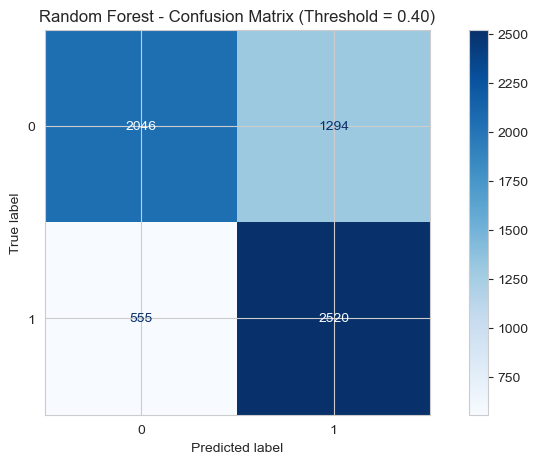

In [61]:
# Predizioni con soglia 0.40
y_val_pred_040 = (y_val_prob >= 0.40).astype(int)

# Matrice di confusione
ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred_040,
    cmap="Blues"
)

plt.title("Random Forest - Confusion Matrix (Threshold = 0.40)")
plt.show()

Con la soglia 0,40 il modello identifica correttamente **2.499** eventi di bleaching (veri positivi) e ne perde **576** (falsi negativi), un netto miglioramento rispetto alla soglia standard. I falsi positivi salgono a **1.276**: il prezzo da pagare per una maggiore sensibilità. Nel complesso classifica correttamente **4.563 osservazioni su 6.415 (≈ 71%)**, in linea con l'obiettivo di privilegiare la Recall nel monitoraggio del bleaching.

### Curva ROC

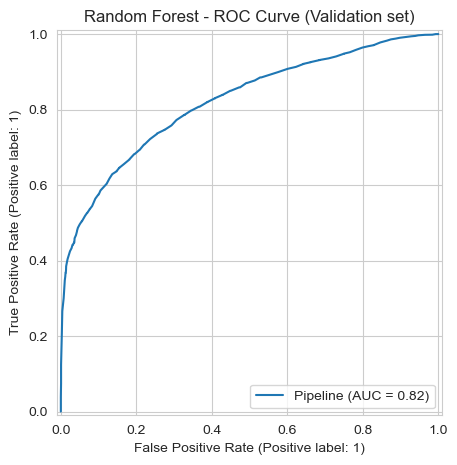

In [62]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    forest,
    X_val,
    y_val
)

plt.title("Random Forest - ROC Curve (Validation set)")
plt.show()

La curva ROC conferma la buona capacità discriminante della Random Forest, con una **ROC-AUC di 0,82** sul validation set: il modello separa efficacemente le due classi indipendentemente dalla soglia scelta.

### Feature importance

In [63]:
# Recupero dei nomi delle feature dopo il preprocessing
feature_names = forest.named_steps["preprocessor"].get_feature_names_out()

# Importanza delle feature della Random Forest
importances = forest.named_steps["classifier"].feature_importances_

feature_importance = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

display(feature_importance.head(20))

,Feature,Importance
8,num__Depth_m,0.049
1,num__Longitude_Degrees,0.048
18,num__SSTA_Standard_Deviation,0.048
7,num__Date_Year,0.043
0,num__Latitude_Degrees,0.043
2,num__Distance_to_Shore,0.039
9,num__Percent_Cover,0.039
5,num__Date_Day,0.033
11,num__Temperature_Kelvin,0.031
29,num__TSA,0.028


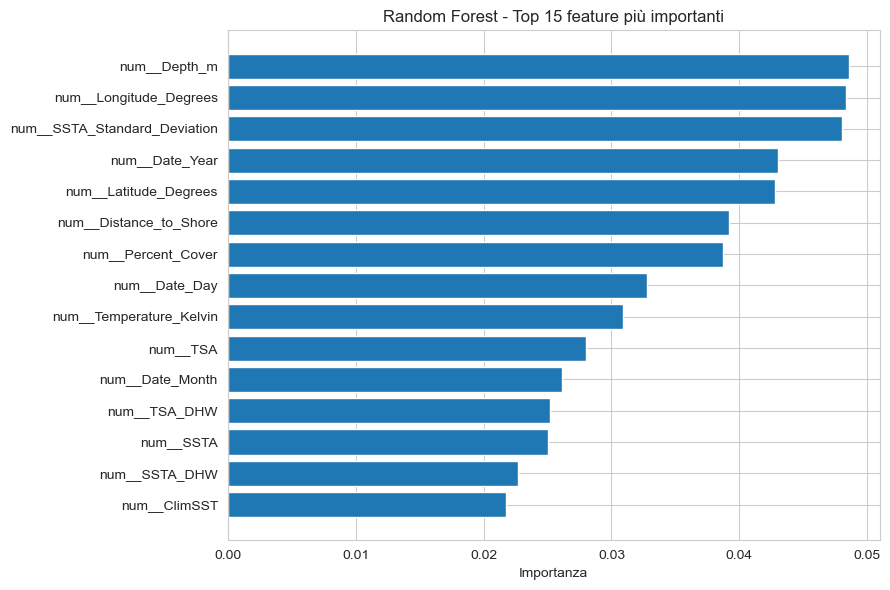

In [64]:
# Visualizzazione delle 15 feature più importanti
top15 = feature_importance.head(15).iloc[::-1]

plt.figure(figsize=(9, 6))
plt.barh(top15["Feature"], top15["Importance"])
plt.xlabel("Importanza")
plt.title("Random Forest - Top 15 feature più importanti")
plt.tight_layout()
plt.show()

Le feature più importanti sono un insieme di variabili ambientali, geografiche e temporali: profondità (`Depth_m`), anno (`Date_Year`), longitudine, variabilità dello stress termico (`SSTA_Standard_Deviation`) e distanza dalla costa figurano tra le prime posizioni. Nessuna variabile domina da sola: il modello combina molti fattori, coerentemente con la natura multifattoriale del fenomeno.

## 7.4 Ottimizzazione degli iperparametri (Random Forest)

Ottimizziamo la Random Forest con una `GridSearchCV`. Uniamo training e validation e usiamo una `GroupKFold` sui cluster geografici, così che la validazione interna rispetti la struttura spaziale. Il test set resta escluso.

In [65]:

# Uniamo training e validation: la GridSearch farà la validazione internamente
X_cv = pd.concat([X_train, X_val], axis=0)
y_cv = pd.concat([y_train, y_val], axis=0)

# Gruppi geografici associati (per la GroupKFold)
groups_cv = df_final.loc[X_cv.index, "site_cluster"]

# Sicurezza: il test set NON deve essere incluso
assert len(X_cv.index.intersection(X_test.index)) == 0
print("Osservazioni per la GridSearch:", len(X_cv))
print("Cluster geografici:", groups_cv.nunique())

Osservazioni per la GridSearch: 27001
Cluster geografici: 2229


In [ ]:
# Griglia di iperparametri
param_grid = {
    "classifier__n_estimators": [300],
    "classifier__max_depth": [None, 20],
    "classifier__min_samples_leaf": [1, 5]
}

grid_search = GridSearchCV(
    estimator=forest,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=GroupKFold(n_splits=3),
    n_jobs=-1
)

# passiamo i gruppi affinché la GroupKFold rispetti i cluster geografici
grid_search.fit(X_cv, y_cv, groups=groups_cv)

print("Migliori iperparametri:", grid_search.best_params_)
print(
    f"Migliore ROC-AUC media nella cross-validation interna della GridSearchCV: "
    f"{grid_search.best_score_:.3f}"
)

La ricerca individua come combinazione migliore `max_depth=20`, `min_samples_leaf=5`, `n_estimators=300`, con una **ROC-AUC media in cross-validation di 0,852**. La cross-validation è calcolata su **27.001** osservazioni raggruppate in **2.229** cluster geografici.

In [ ]:
# Modello ottimizzato: GridSearchCV lo ha già riaddestrato su tutto X_cv
# usando la migliore combinazione di iperparametri trovata.
best_forest = grid_search.best_estimator_
print("Modello ottimizzato pronto.")
print("Iperparametri finali:", grid_search.best_params_)

Prima di valutare il modello ottimizzato, si precisa che la soglia decisionale pari a 0,40 è stata selezionata sulla Random Forest di base e mantenuta anche per la configurazione ottimizzata, così da preservare coerenza con l’analisi precedente.

La soglia non è stata nuovamente selezionata sulle probabilità prodotte dal modello ottimizzato. Poiché configurazioni differenti possono generare distribuzioni delle probabilità differenti, una scelta specifica della soglia per il modello finale potrebbe produrre risultati diversi. Tale aspetto rappresenta un limite dell’analisi.

## 7.5 Valutazione finale sul test set
Valutiamo il modello ottimizzato sul test set, rimasto escluso dalle fasi di confronto tra modelli e di selezione degli iperparametri. Per le predizioni viene mantenuta la soglia decisionale pari a 0,40 scelta nell’analisi precedente.

In [ ]:
# Probabilità e predizioni sul test set (modello ottimizzato)
y_test_prob = best_forest.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= 0.40).astype(int)

test_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Value": [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred),
        roc_auc_score(y_test, y_test_prob)
    ]
}).round(3)

test_results

Sul test set, la Random Forest ottimizzata raggiunge una ROC-AUC pari a 0,911, indicando una buona capacità discriminante. Con la soglia decisionale fissata a 0,40, il modello ottiene una Recall elevata, pari a 0,901, a fronte di una Precision pari a 0,804. L’F1-score pari a 0,850 mostra un buon equilibrio tra capacità di individuare i casi positivi e contenimento dei falsi positivi.

La soglia più bassa rispetto al valore standard di 0,50 favorisce il riconoscimento dei casi di bleaching, aumentando la Recall. I risultati devono tuttavia essere interpretati considerando che la soglia è stata selezionata sul modello di base e successivamente mantenuta per il modello ottimizzato.

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, cmap="Greens")
plt.title("Random Forest ottimizzata - Confusion Matrix (Test set)")
plt.show()

La matrice di confusione mostra che il modello classifica correttamente 2.197 casi negativi e 3.892 casi positivi. Gli errori comprendono 951 falsi positivi e 427 falsi negativi.

Nel complesso, il modello riconosce efficacemente la classe positiva, mantenendo un numero contenuto di falsi negativi.

## 7.6 Analisi della variabilità delle prestazioni

Confrontiamo la composizione dei tre insiemi per interpretare correttamente le differenze di prestazione.

In [ ]:
def summarize_split(indices):
    subset = df_final.loc[indices]
    return pd.Series({
        "Osservazioni": len(subset),
        "Cluster geografici": subset["site_cluster"].nunique(),
        "Bleaching rate": subset["Bleaching_Occurrence"].mean(),
        "Reef_Check": subset["Data_Source"].eq("Reef_Check").mean(),
        "Donner": subset["Data_Source"].eq("Donner").mean(),
        "Pacific": subset["Ocean_Name"].eq("Pacific").mean(),
        "Atlantic": subset["Ocean_Name"].eq("Atlantic").mean()
    })

split_comparison = pd.DataFrame({
    "Training": summarize_split(X_train.index),
    "Validation": summarize_split(X_val.index),
    "Test": summarize_split(X_test.index)
}).T.round(3)

split_comparison

I tre insiemi differiscono nella composizione: il test set presenta un tasso di bleaching più alto rispetto al training e una diversa distribuzione delle fonti e degli oceani. Queste differenze derivano dallo split geografico, che separa aree differenti e consente di valutare il modello su regioni non utilizzate durante l’addestramento.

Le differenze osservate tra le prestazioni su validation e test devono quindi essere interpretate anche alla luce della diversa composizione dei tre insiemi.

# **8. Conclusioni**

In questo progetto è stato sviluppato un modello di Machine Learning per prevedere la presenza di coral bleaching a partire da variabili ambientali, climatiche, temporali e geografiche.

Il dataset è complesso: le stesse aree vengono campionate più volte, le fonti si comportano in modo diverso e gli eventi di bleaching non sono distribuiti uniformemente. Proprio per questa forte componente spaziale, la suddivisione e la validazione sono state condotte per cluster geografici

Tra i modelli confrontati — Logistic Regression, Decision Tree e Random Forest — la Random Forest ha ottenuto le prestazioni migliori. Dopo l’ottimizzazione degli iperparametri mediante `GridSearchCV` con validazione geografica interna, il modello finale ha raggiunto sul test set una ROC-AUC pari a 0,911, un’Accuracy di 0,815 e un F1-score di 0,850. La Recall pari a 0,901 indica una buona capacità di riconoscere gli eventi reali di bleaching.

L’analisi delle feature importance suggerisce che le predizioni dipendono dalla combinazione di fattori ambientali, geografici e temporali, tra cui profondità, posizione geografica, variabili associate allo stress termico e distanza dalla costa.


### Limiti e possibili sviluppi futuri

* **Costruzione dei cluster geografici.**
  Un primo limite riguarda la costruzione dei cluster geografici. I gruppi sono stati definiti mediante arrotondamento delle coordinate, una soluzione semplice e trasparente che però non rappresenta sempre in modo preciso la distanza reale tra i siti. Osservazioni geograficamente vicine potrebbero essere assegnate a gruppi diversi, mentre altre più distanti potrebbero ricadere nello stesso cluster. In futuro si potrebbero utilizzare metodi basati direttamente sulla distanza, come DBSCAN, oppure soglie geografiche espresse in chilometri.

* **Mancata stratificazione simultanea.**
  La suddivisione dei dati ha rispettato i gruppi geografici, ma non è stata contemporaneamente stratificata rispetto alla variabile target, alla fonte di raccolta o all’area oceanica. Di conseguenza, training, validation e test presentano composizioni differenti, sia nel tasso di bleaching sia nella distribuzione delle fonti e delle regioni. Queste differenze non invalidano la valutazione, ma possono influenzare le metriche e rendere più complesso il confronto tra gli insiemi. Un possibile miglioramento sarebbe l’impiego di `StratifiedGroupKFold`, accompagnato da un controllo della composizione dei singoli fold.

* **Singolo test set geografico.**
  La stima finale delle prestazioni deriva da un singolo test set geografico. Una valutazione più robusta potrebbe essere ottenuta mediante più suddivisioni geografiche indipendenti oppure attraverso una nested cross-validation, in cui la selezione degli iperparametri e la stima delle prestazioni avvengono in cicli separati.

* **Scelta della soglia decisionale.**
  Un ulteriore limite riguarda la soglia decisionale pari a 0,40, selezionata sulla Random Forest di base e successivamente mantenuta per il modello ottimizzato. Poiché configurazioni differenti possono produrre probabilità distribuite in modo diverso, una nuova selezione della soglia sul modello finale potrebbe portare a risultati differenti. In futuro la soglia potrebbe essere definita tramite predizioni out-of-fold e un criterio operativo stabilito a priori.

* **Classificazione binaria.**
  Il problema è stato formulato come classificazione binaria, distinguendo soltanto tra presenza e assenza di bleaching. Questa scelta semplifica il fenomeno e non permette di distinguere eventi lievi, moderati o severi. Sviluppi futuri potrebbero prevedere una classificazione multiclasse, un modello ordinale oppure una regressione sulla percentuale di bleaching.

